# **Embedded-based Feature Selection:**
- Lasso Regression
- Ridge Regression
- Random Forest Feature Importance

Embedde-based feature selection methods are type of methods that our selection is based on the models special characteristics we can say our feature selection method is implanted into the models structure like regularization techniques used in the models to penalize them for lower coefficientts.

Examples of embedded-based feature selection methods are Lasso regression (regression with L1 regularization) and Ridge Regression (regression with L2 regularization) and we can use random forest feature importance to select features with higher feature importance than a threshold we set.

In general I think we can use regularization techniques (that means adding a regularization paramter to the model cost function) to use their ability of reducing the magnitude of the feature coefs and then we can decide to select which features based-on their importance.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets

In [7]:
# loading a dataset suitable for regression task
diabetes_data = datasets.load_diabetes()
diabetes = pd.concat(
    [
        pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names),
        pd.Series(diabetes_data.target, name="target")
	],
    axis=1
)

diabetes

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


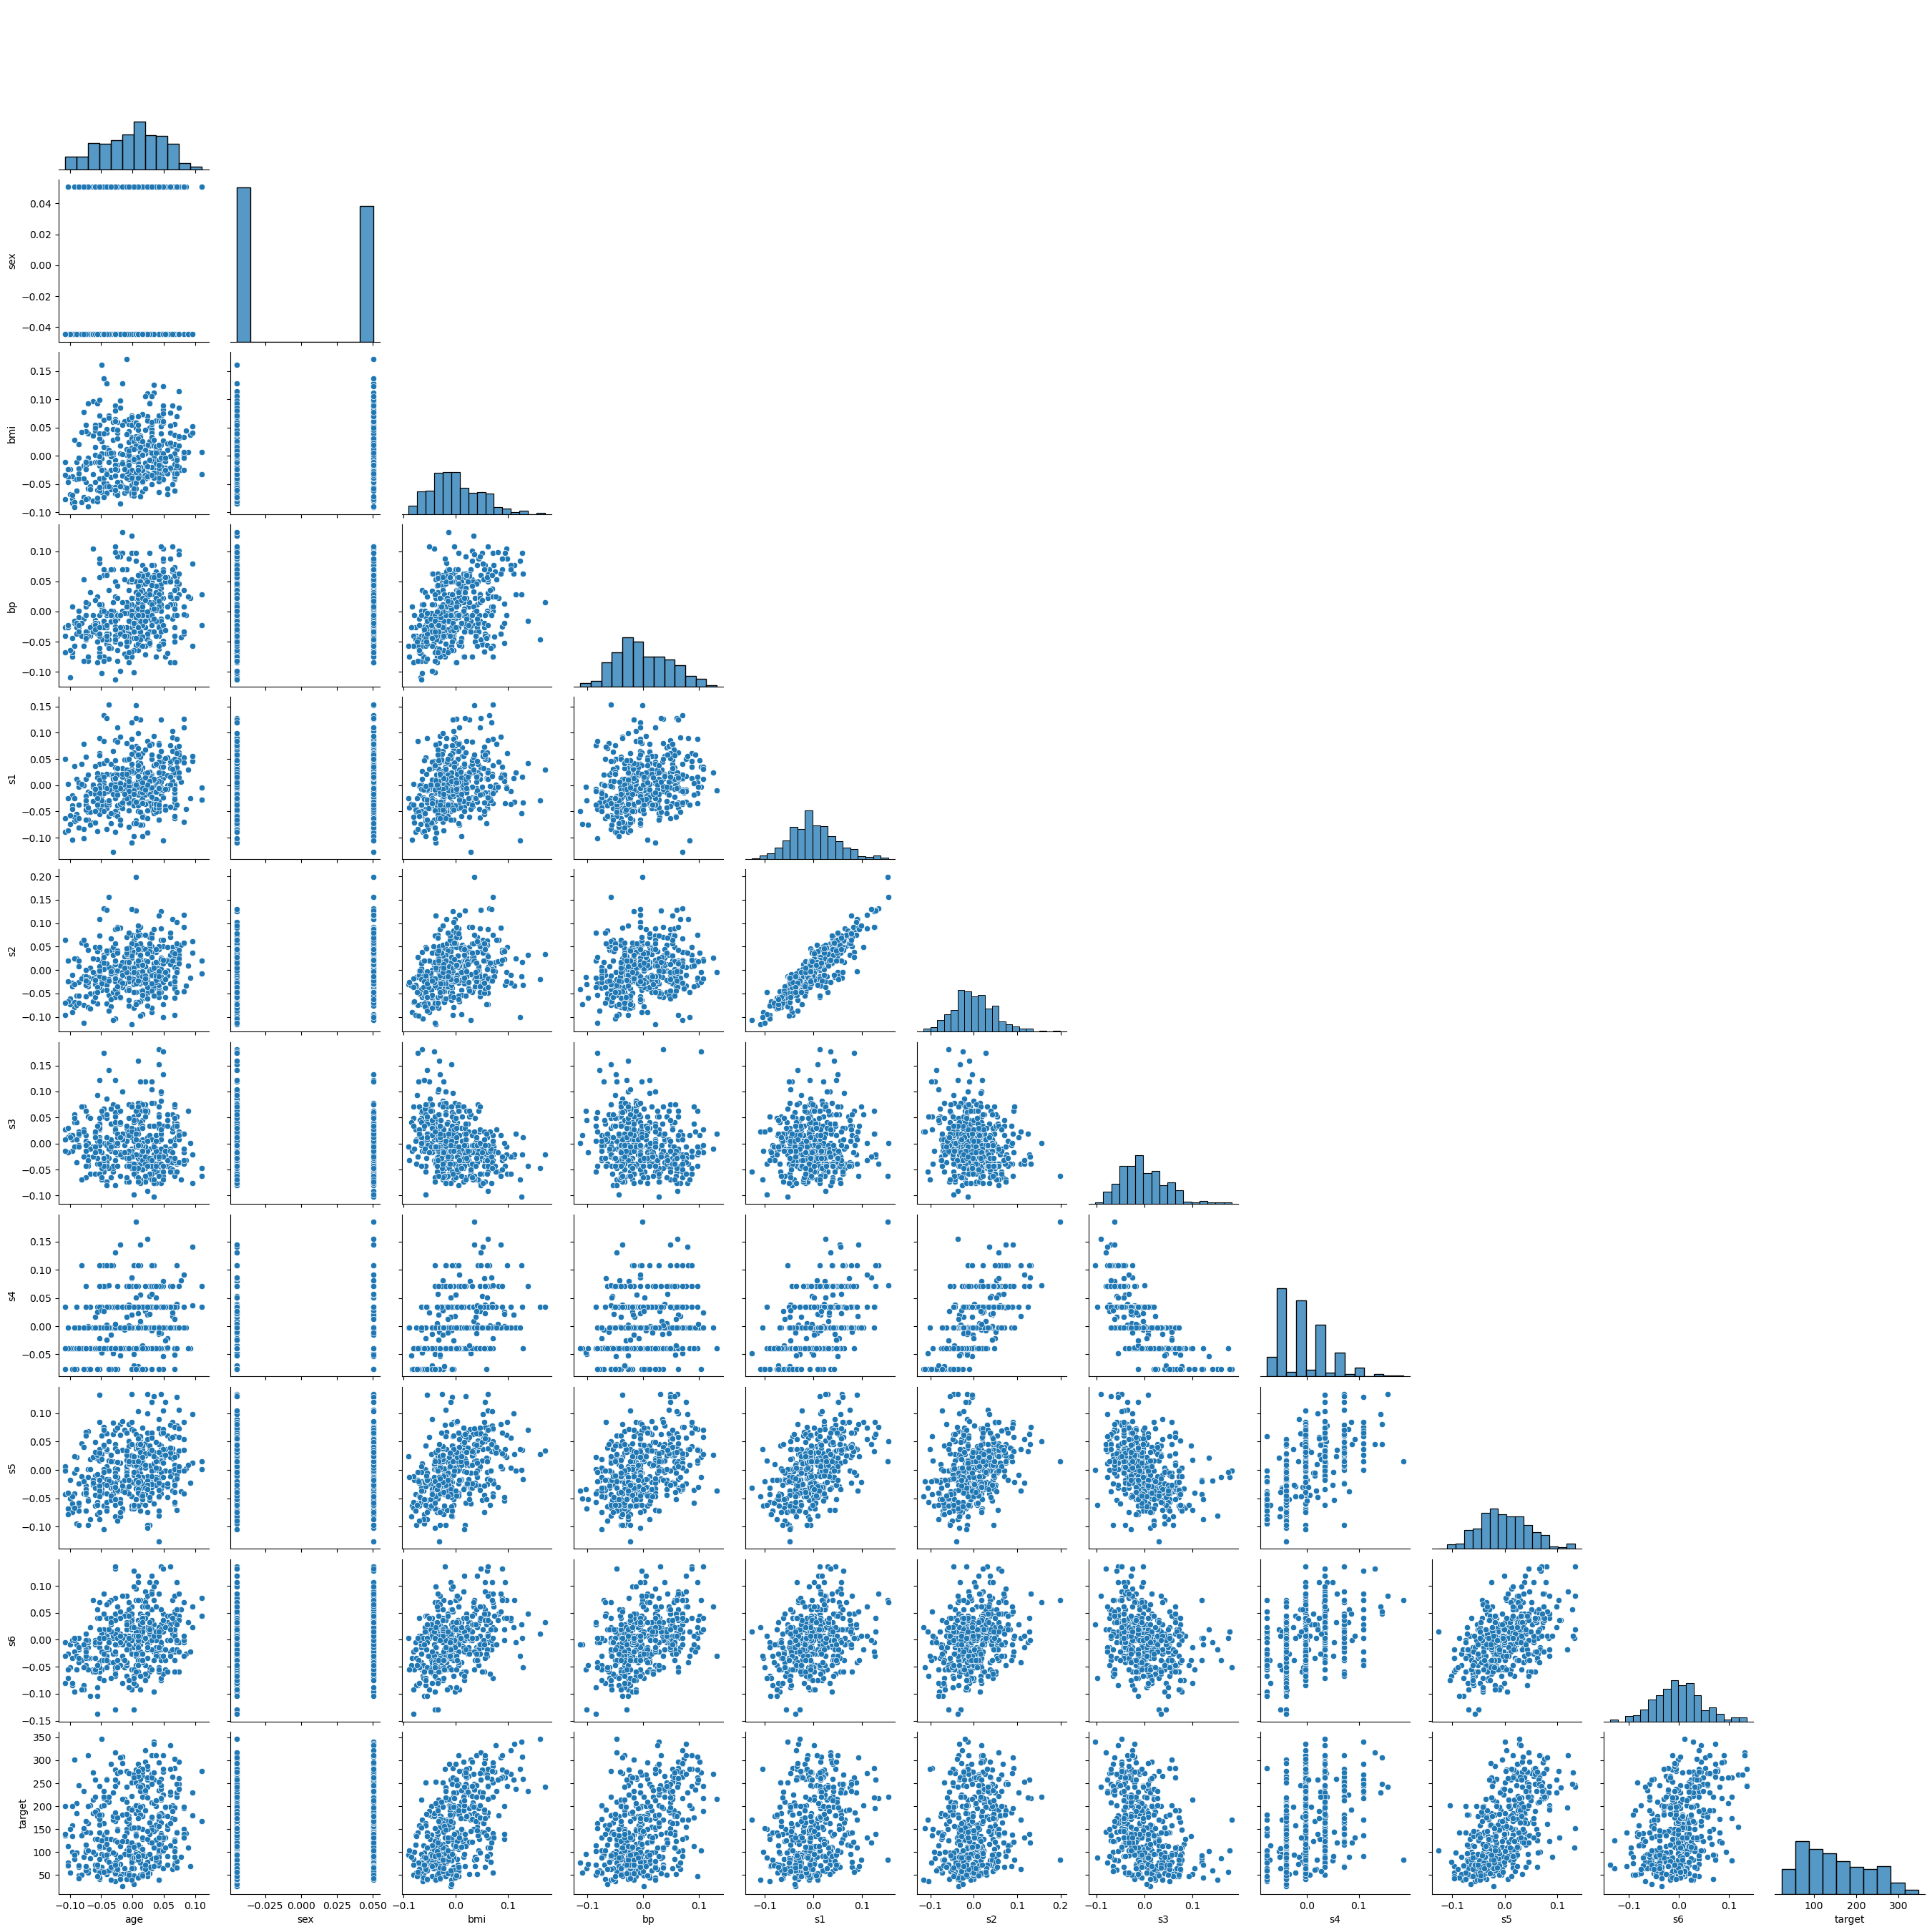

In [10]:
sns.pairplot(
    data=diabetes,
    corner=True
)

by looking at the scatter plots we can see maybe the most valiable relationship in our dataset is the relation ship between s1 and s2 that we can model this relation ship using a line.

## Lasso Regression:

In [13]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

X = diabetes_data.data
y = diabetes_data.target

# scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# model training
lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [25]:
coefs_df = pd.DataFrame(
    data=abs(lasso.coef_),
    index=diabetes_data.feature_names,
	columns=["coef"]
)

coefs_df.sort_values(by="coef", ascending=False)

,coef
s5,31.575062
s1,26.448140
bmi,24.855184
bp,15.242133
s2,13.725663
sex,11.159488
s4,7.055574
s6,3.158477
age,0.277693
s3,0.000000


L1 regularization assumes a exponential distribution on the coefficient values so it uses more power to make the coefficients zero than the L2 regularization that assumes a normal distribution on them. Lasso regularization method usually results in sparse coefficient vectors and make many of the coefficiens exactly zero so it's more useful for high dimensional data.

## Ridge Regression:

In [27]:
from sklearn.linear_model import Ridge

# training the model
ridge = Ridge(alpha=0.1)
ridge.fit(X_scaled, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [30]:
coefs_df = pd.DataFrame(
    data=abs(ridge.coef_),
    index=diabetes_data.feature_names,
	columns=["coef"]
)

coefs_df.sort_values(by="coef", ascending=False)

,coef
s1,36.744995
s5,35.379812
bmi,24.733061
s2,21.934286
bp,15.423015
sex,11.398633
s4,8.309680
s3,4.393211
s6,3.222300
age,0.470814


Ridge regression is less aggresive in penalizing the coefficients so maybe we can see many coefficients that are not exactly equal to zero but they are very small.

Be aware that using lasso and ridge for classification suitable data is possible too.

## Random Forest Feature Importance:

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_scaled, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
coefs_df = pd.DataFrame(
    data=rf_clf.feature_importances_,
    index=diabetes_data.feature_names,
	columns=["coef"]
)

coefs_df.sort_values(by="coef", ascending=False)

,coef
bmi,0.121665
s5,0.119679
bp,0.117954
s2,0.112527
s6,0.112249
age,0.110986
s1,0.109398
s3,0.107793
s4,0.060983
sex,0.026766


In [44]:
# comparing all results
coef_df = pd.concat(
    [
        pd.DataFrame(data=abs(lasso.coef_), index=diabetes_data.feature_names, columns=["lasso_coef"]),
        pd.DataFrame(data=abs(ridge.coef_), index=diabetes_data.feature_names, columns=["ridge_coef"]),
        pd.DataFrame(data=rf_clf.feature_importances_, index=diabetes_data.feature_names, columns=["rf_feature_importance"])
	],
    axis=1
)

coef_df.sort_values(by="lasso_coef", ascending=False)

,lasso_coef,ridge_coef,rf_feature_importance
s5,31.575062,35.379812,0.119679
s1,26.448140,36.744995,0.109398
bmi,24.855184,24.733061,0.121665
bp,15.242133,15.423015,0.117954
s2,13.725663,21.934286,0.112527
sex,11.159488,11.398633,0.026766
s4,7.055574,8.309680,0.060983
s6,3.158477,3.222300,0.112249
age,0.277693,0.470814,0.110986
s3,0.000000,4.393211,0.107793


<Axes: xlabel='None', ylabel='rf_feature_importance'>

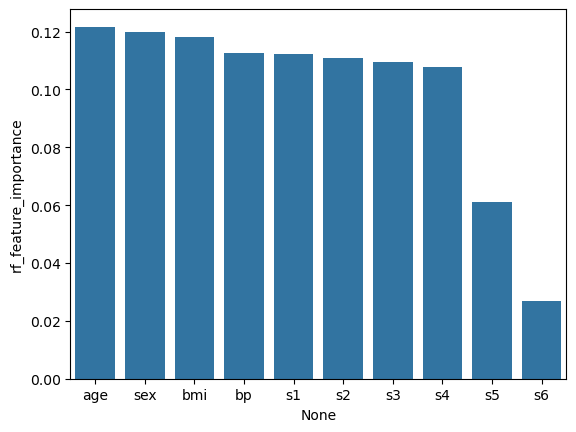

In [48]:
sns.barplot(
    data=coef_df.sort_values(by="rf_feature_importance", ascending=False),
    x=coef_df.index,
    y="rf_feature_importance"
)

Now with a more comprehensive view to the data we can decide to remove or choose which features.

Always try different methods or even different combinations to find the best results for your specific goal and data. Using hybrid methods is so useful and most of the times results in better conclusions.

At first when dealing with a data after the feature creation and feature transformation parts in the feature engineering when you are trying to do a feature selection task always be aware to at first use filter-based methods and then with the insights and results from them try proceeding to the wrapper-based or embedded-based methods.

Always be curious and experiments your ideas :)